# Heisenberg — Wine

Exemplo da API `fit()/transform()` com **6 features fixas** e todas as 178 amostras do dataset Wine. O alvo binário é a classe 0 versus as demais.

O Heisenberg não calcula mutual information. Ainda assim, ele permanece dentro do pipeline para que scaler, estrutura, layout e circuito sejam ajustados somente com o treino de cada fold.

O notebook faz uma comparação direta entre um modelo clássico treinado com as features originais e um modelo treinado somente com as features quânticas produzidas pelo PQFM.

In [15]:
from __future__ import annotations

from getpass import getpass
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
IDEAL = False
SIMULATION = True
SHOTS = 4096
IBM_BACKEND_NAME = "ibm_kingston"

from sklearn.datasets import load_wine

from pqfmlib import HeisenbergProjectiveQFM

## Credenciais IBM para `ideal=False`

O modo padrão é `IDEAL = True` e não solicita credenciais. Para testar `ideal=False`, altere essa variável na primeira célula.

A célula seguinte solicitará o token sem exibi-lo e o disponibilizará aos clones pela variável de ambiente `QISKIT_IBM_TOKEN`. O token não será salvo em arquivo pelo notebook. O único backend carregado será `ibm_kingston`.

A execução continua com `simulation=True` e `fakebackend=True`: as propriedades do Kingston são usadas na simulação, mas nenhum job é submetido à QPU.

In [16]:
if not IDEAL:
    print("O token é usado somente nesta sessão e não será salvo pelo notebook.")
    os.environ["QISKIT_IBM_TOKEN"] = getpass("IBM Cloud API token")

O token é usado somente nesta sessão e não será salvo pelo notebook.


IBM Cloud API token ········


In [17]:
dataset = load_wine(as_frame=True)
selected_features = [
    "alcohol",
    "malic_acid",
    "ash",
    "alcalinity_of_ash",
    "magnesium",
    "total_phenols",
]
X = dataset.data.loc[:, selected_features].copy()
y = (dataset.target.to_numpy() == 0).astype(int)  # classe 0 = positiva
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols
0,14.23,1.71,2.43,15.6,127.0,2.80
1,13.20,1.78,2.14,11.2,100.0,2.65
2,13.16,2.36,2.67,18.6,101.0,2.80
3,14.37,1.95,2.50,16.8,113.0,3.85
4,13.24,2.59,2.87,21.0,118.0,2.80


In [18]:
pqfm = HeisenbergProjectiveQFM(
    name_file="wine_grid_search",
    seed=SEED,
    ideal=IDEAL,
    simulation=SIMULATION,
    fakebackend=not IDEAL,
    shots=SHOTS,
    ibm_qpu=IBM_BACKEND_NAME,
    q_enc=6,
    R=1,
    alpha=0.1,
    use_tanh_scaling=True,
    use_gpu_statevector=False,
)

## Comparação com GridSearchCV nos 80% de treino

Dois modelos são ajustados com os mesmos cinco folds e a mesma grade de hiperparâmetros:

- **Clássico:** features originais escaladas → GradientBoosting.
- **PQFM:** features originais escaladas → PQFM → GradientBoosting.

O critério de seleção é exclusivamente ROC-AUC. O threshold final permanece no valor padrão `0.5`.

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEED,
    stratify=y,
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

classical_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("classifier", GradientBoostingClassifier(random_state=SEED)),
    ]
)

quantum_pipeline = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("pqfm", pqfm),
        ("classifier", GradientBoostingClassifier(random_state=SEED)),
    ]
)

parameter_grid = {
    "classifier__n_estimators": [50, 100],
    "classifier__learning_rate": [0.05],
    "classifier__max_depth": [1, 2],
}


def make_grid_search(pipeline):
    return GridSearchCV(
        estimator=pipeline,
        param_grid=parameter_grid,
        scoring="roc_auc",
        cv=cv,
        refit=True,
        n_jobs=1,
        return_train_score=False,
        verbose=1,
    )


classical_search = make_grid_search(classical_pipeline)
quantum_search = make_grid_search(quantum_pipeline)

classical_search.fit(X_train, y_train)
quantum_search.fit(X_train, y_train)

cv_comparison = pd.DataFrame(
    {
        "Modelo": ["Clássico", "PQFM"],
        "Melhor ROC-AUC CV": [
            classical_search.best_score_,
            quantum_search.best_score_,
        ],
        "Melhores hiperparâmetros": [
            classical_search.best_params_,
            quantum_search.best_params_,
        ],
    }
).set_index("Modelo")

print(f"Dataset completo: {len(X)} amostras")
print(f"Treino/GridSearchCV: {len(X_train)} amostras")
print(f"Teste final: {len(X_test)} amostras")
display(cv_comparison)

Fitting 5 folds for each of 4 candidates, totalling 20 fits


qiskit_runtime_service._discover_account:WARNING:2026-08-19 18:35:51,797: Loading account with the given token. A saved account will not be used.


Fitting 5 folds for each of 4 candidates, totalling 20 fits


qiskit_runtime_service.__init__:WARNING:2026-08-19 18:36:02,272: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: qiskir2025. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-08-19 18:36:02,273: Using instance: qiskir2025, plan: open
qiskit_runtime_service._discover_account:WARNING:2026-08-19 18:36:43,602: Loading account with the given token. A saved account will not be used.
qiskit_runtime_service.__init__:WARNING:2026-08-19 18:36:46,683: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the

Dataset completo: 178 amostras
Treino/GridSearchCV: 142 amostras
Teste final: 36 amostras


,Melhor ROC-AUC CV,Melhores hiperparâmetros
Modelo,,
Clássico,0.989708,"{'classifier__learning_rate': 0.05, 'classifie..."
PQFM,0.973333,"{'classifier__learning_rate': 0.05, 'classifie..."


## Comparação final nos 20% de teste

Os dois melhores estimadores são avaliados uma única vez no mesmo conjunto de teste, que não participa da escolha dos hiperparâmetros.

In [20]:
def evaluate_on_test(search):
    probabilities = search.predict_proba(X_test)[:, 1]
    predictions = search.predict(X_test)
    metrics = {
        "ROC-AUC": roc_auc_score(y_test, probabilities),
        "Recall": recall_score(y_test, predictions, zero_division=0),
        "Precision": precision_score(y_test, predictions, zero_division=0),
        "F1-score": f1_score(y_test, predictions, zero_division=0),
        "Accuracy": accuracy_score(y_test, predictions),
    }
    return metrics, probabilities, predictions


classical_metrics, classical_probabilities, classical_predictions = evaluate_on_test(
    classical_search
)
quantum_metrics, quantum_probabilities, quantum_predictions = evaluate_on_test(
    quantum_search
)

test_comparison = pd.DataFrame(
    {
        "Clássico": classical_metrics,
        "PQFM": quantum_metrics,
    }
).T
test_comparison.index.name = "Modelo"
display(test_comparison)

best_pqfm = quantum_search.best_estimator_.named_steps["pqfm"]
scaled_example = quantum_search.best_estimator_.named_steps["scaler"].transform(
    X_test.iloc[:1]
)
n_quantum_features = best_pqfm.transform(scaled_example).shape[1]
print("Número de features clássicas:", X.shape[1])
print("Número de features quânticas:", n_quantum_features)
print("Nós físicos do melhor PQFM:", getattr(best_pqfm, "phys_nodes", None))

,ROC-AUC,Recall,Precision,F1-score,Accuracy
Modelo,,,,,
Clássico,0.975694,0.916667,0.846154,0.88,0.916667
PQFM,0.921875,0.833333,0.769231,0.80,0.861111


Número de features clássicas: 6
Número de features quânticas: 18
Nós físicos do melhor PQFM: [123, 136, 143, 142, 141, 140]


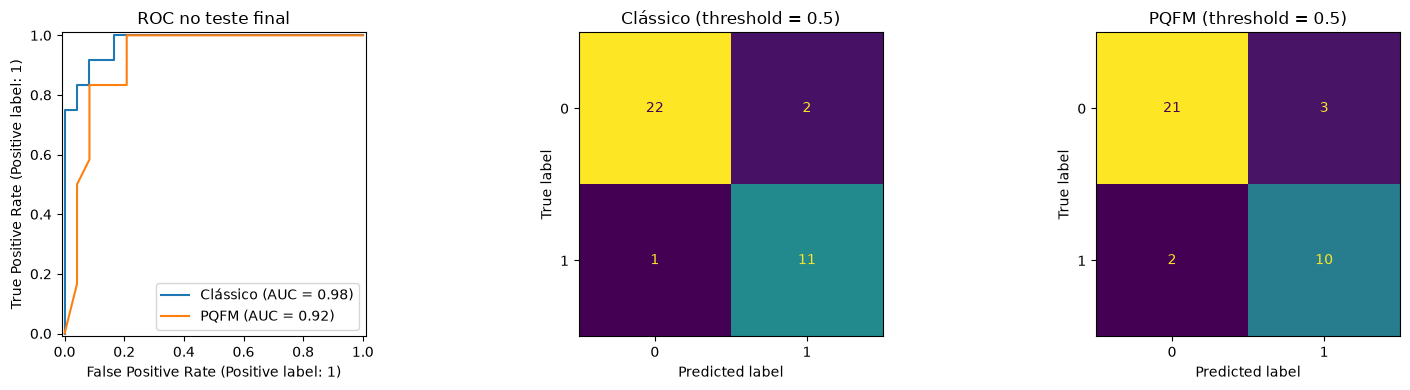

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

RocCurveDisplay.from_predictions(
    y_test,
    classical_probabilities,
    name="Clássico",
    ax=axes[0],
)
RocCurveDisplay.from_predictions(
    y_test,
    quantum_probabilities,
    name="PQFM",
    ax=axes[0],
)
axes[0].set_title("ROC no teste final")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    classical_predictions,
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title("Clássico (threshold = 0.5)")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    quantum_predictions,
    ax=axes[2],
    colorbar=False,
)
axes[2].set_title("PQFM (threshold = 0.5)")

plt.tight_layout()
plt.show()